### Read ME
    
Before running the program, please make sure the library have installed on your environment. 
IF get the error ModuleNotFoundError: No module named"". That means the library has not been installed.
    
Using pip function install library.  
Example you got error like ModuleNotFoundError: No module named "wfdb". So put & run this code for install wfdb

       pip install "library name"
   
   <B>pip install wfdb</B> 

at new cell of jupyter notebook. Also use this code for install other library 
    
    

In [ ]:
!pip install wfdb

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 137 kB 5.0 MB/s 
     |████████████████████████████████| 11.2 MB 44.1 MB/s 
     |████████████████████████████████| 930 kB 46.0 MB/s 
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.2.2
    Uninstalling matplotlib-3.2.2:
      Successfully uninstalled matplotlib-3.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 0.1.12 requires imgaug<0.2.7,>=0.2.5, but you have imgaug 0.2.9 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import shutil
import posixpath

import wfdb
from wfdb import processing
from PIL import Image
import pandas as pd

Mounted at /content/drive


### ECG Preprocessing
#### First download all data  which can Access at:
    MIT-BIH Normal Sinus Rhythm Database https://physionet.org/content/nsrdb/1.0.0/
    Sudden Cardiac Death Holter Database https://physionet.org/content/sddb/1.0.0/

In [ ]:
# function to read signals and convert in picture
def conv_topict(sig, peak_inds, fs, figsize=(75, 10), saveto=None):
    "Plot a signal with its peaks and heart rate"

    N = sig.shape[0]
    
    fig, ax_left = plt.subplots(figsize=figsize)
    ax_right = ax_left.twinx()
    
    ax_left.plot(sig, color='#3979f0', label='Signal')

    if saveto is not None:
        plt.savefig(saveto, dpi=400)
    plt.show()

### Preprocessing - Normal Dataset

In [ ]:
# Read all of the record on Normal dataset
lines = []

with open('/content/drive/My Drive/Thesis/Data/nsrdb/RECORDS') as f:
    lines = f.readlines()[:-1]

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
lines

['16265',
 '16272',
 '16273',
 '16420',
 '16483',
 '16539',
 '16773',
 '16786',
 '16795',
 '17052',
 '17453',
 '18177',
 '18184',
 '19088',
 '19090',
 '19093',
 '19140']

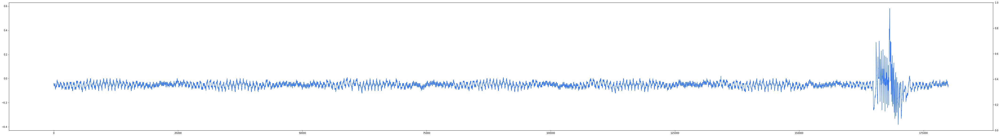

/usr/local/lib/python3.7/dist-packages/PIL/Image.py:2800: DecompressionBombWarning: Image size (120000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  DecompressionBombWarning,


Finishing data 16265


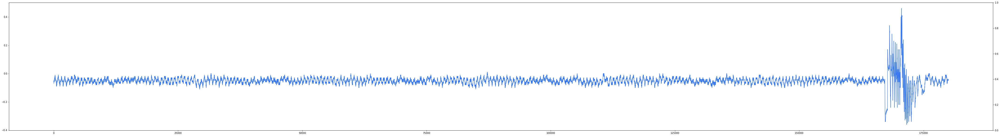

Finishing data 16272


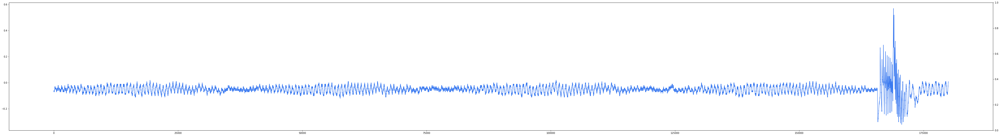

Finishing data 16273


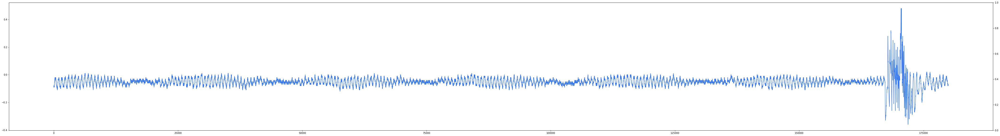

Finishing data 16420


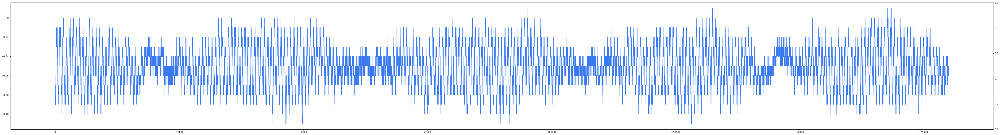

Finishing data 16483


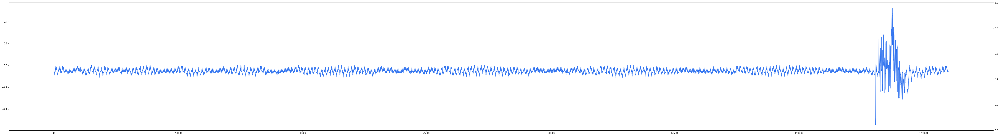

Finishing data 16539


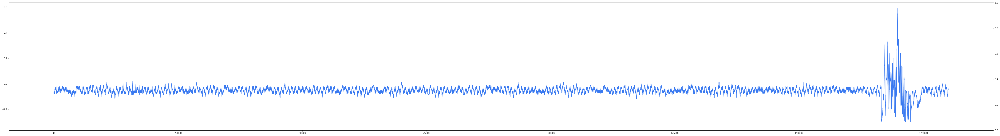

Finishing data 16773


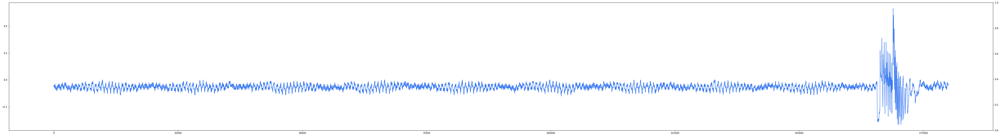

Finishing data 16786


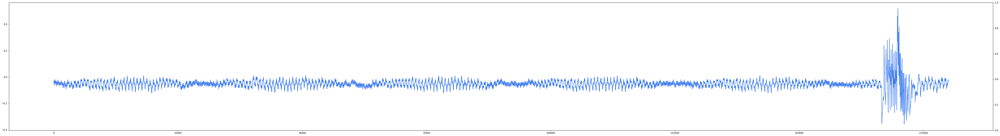

Finishing data 16795


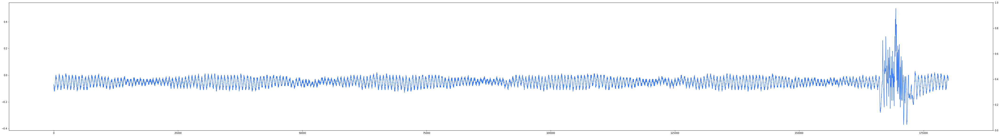

Finishing data 17052


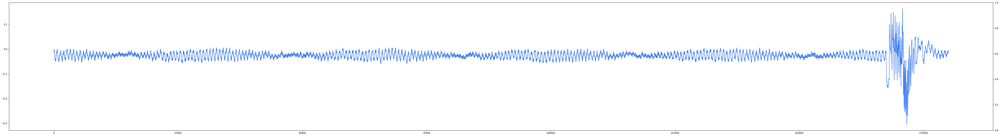

Finishing data 17453


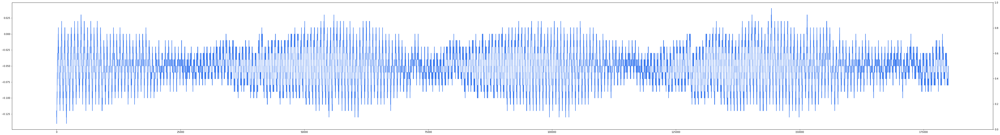

Finishing data 18177


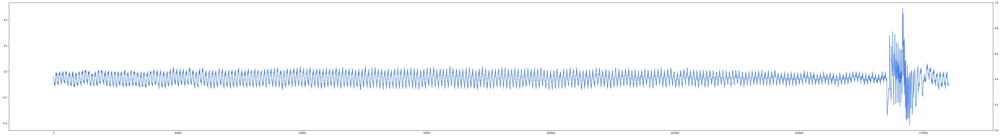

Finishing data 18184


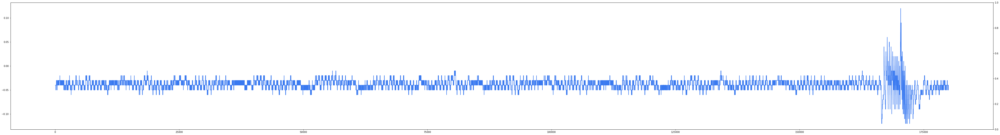

Finishing data 19088


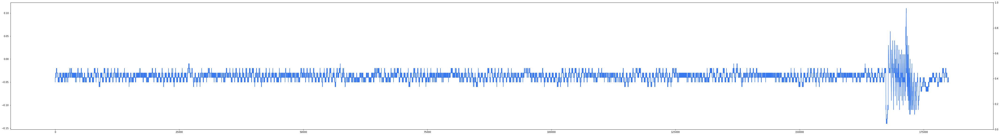

Finishing data 19090


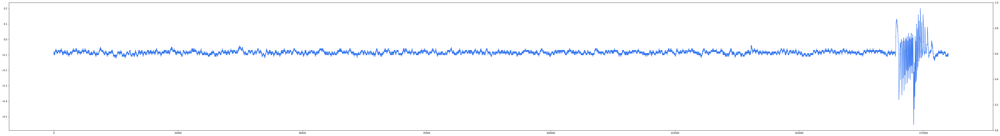

Finishing data 19093


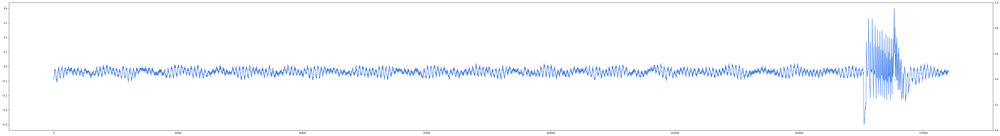

Finishing data 19140


In [ ]:
for v in lines:
    dictory = "/content/drive/My Drive/Thesis/Data/nsrdb/"+v
    
    # Calculate time of start and finish 
    record = wfdb.rdrecord(dictory)
    time = record.sig_len # Get length of time

    # Setup value of time frame
    m = 1000*60*3 # 3 minute

    # setup time start and finish
    start = time-m
    finish = time
    
    # directory for saving file of grayscale
    saveto = "/content/drive/My Drive/Thesis/Picture/Normal/"+v+".png"

    # Load the WFDB record and the physical samples
    record = wfdb.rdrecord(dictory, sampfrom=start, sampto=finish, channels=[0])

    # Use the GQRS algorithm to detect QRS locations in the first channel
    qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

    # Plot results
    conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs, saveto=saveto)

    # open the image and save as grayscale picture
    img = Image.open(saveto).convert('L')
    
    save_img = "/content/drive/My Drive/Thesis/Grayscale/Normal/normal - "+v+".png"
    img.save(save_img)
    
    print('Finishing data '+v)

### Preprocessing - Sudden Cardiac Death Dataset

In [ ]:
# Read all of the record on SCD dataset
lines = []
with open('/content/drive/My Drive/Thesis/Data/sddb/RECORDS') as f:
    lines = f.readlines()[:-1]

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
lines

['30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51']

In [ ]:
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

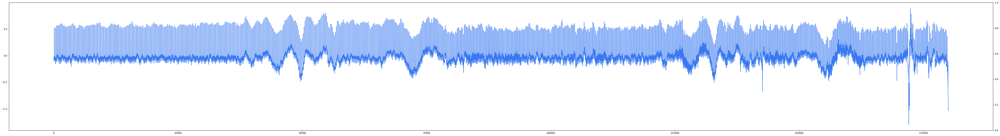

/usr/local/lib/python3.7/dist-packages/PIL/Image.py:2800: DecompressionBombWarning: Image size (120000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  DecompressionBombWarning,


Finishing data 30


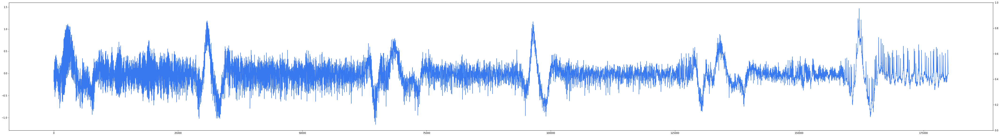

Finishing data 31


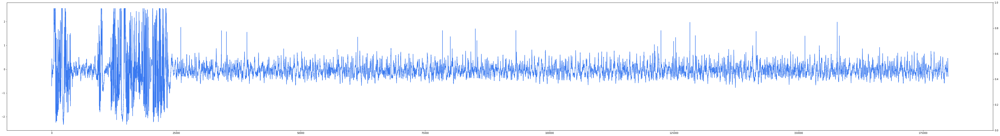

Finishing data 32


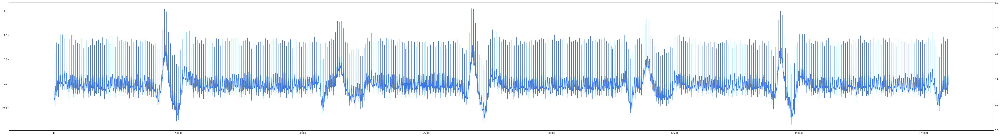

Finishing data 33


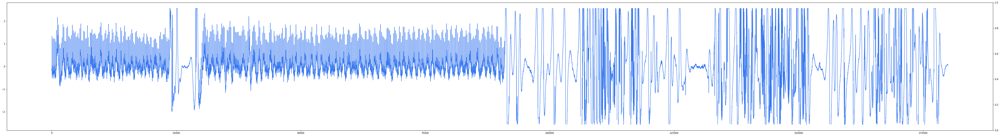

Finishing data 34


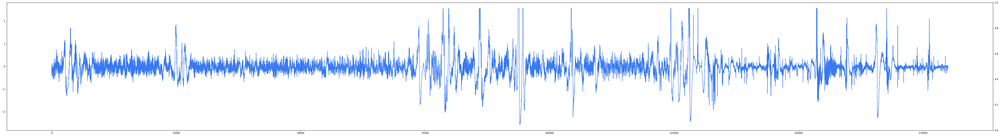

Finishing data 35


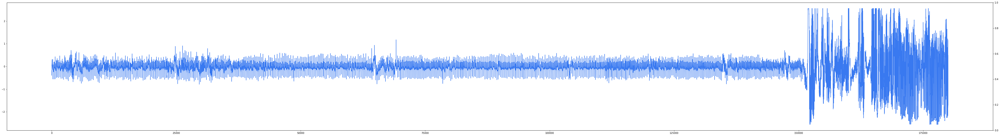

Finishing data 36


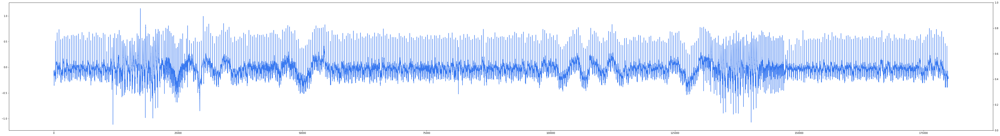

Finishing data 37


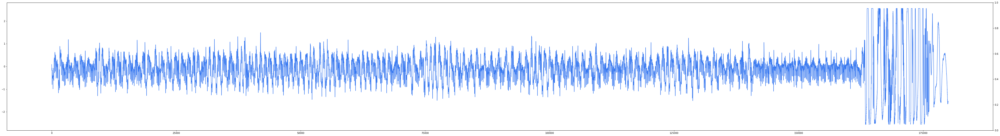

Finishing data 38


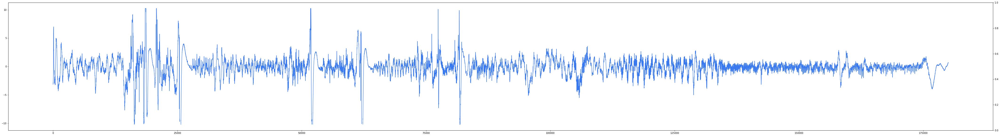

Finishing data 39


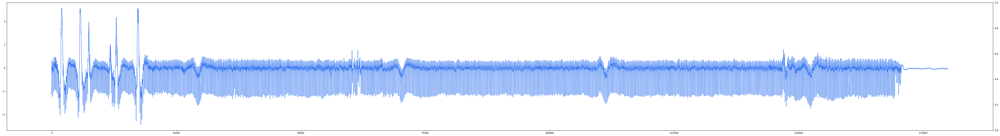

Finishing data 40


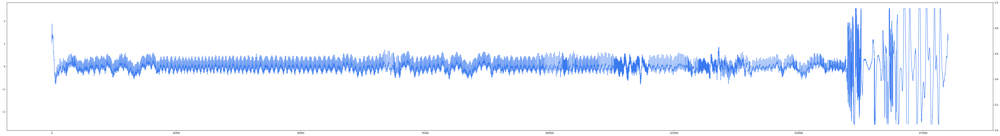

Finishing data 41


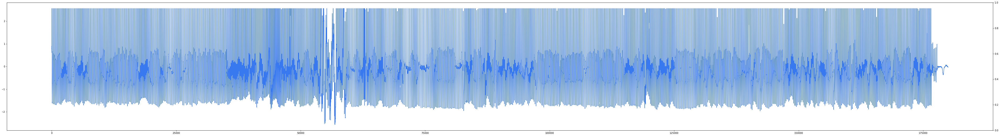

Finishing data 42


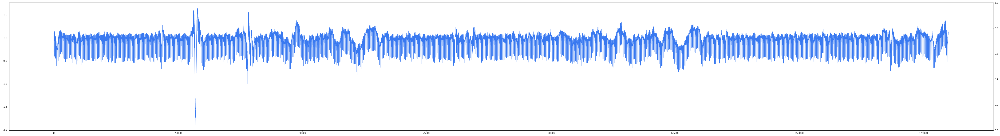

Finishing data 43


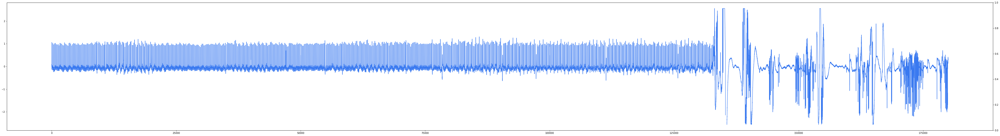

Finishing data 44


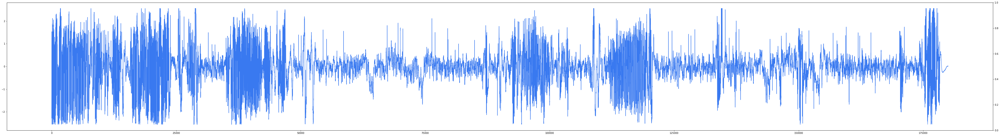

Finishing data 45


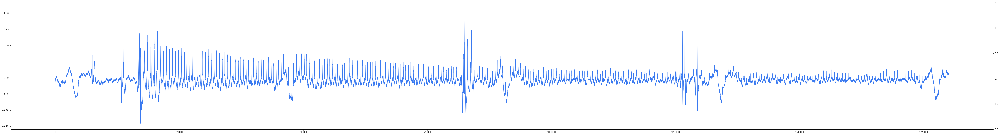

Finishing data 46


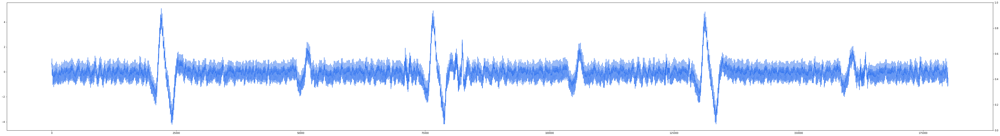

Finishing data 47


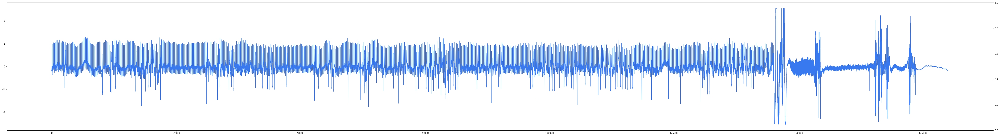

Finishing data 48


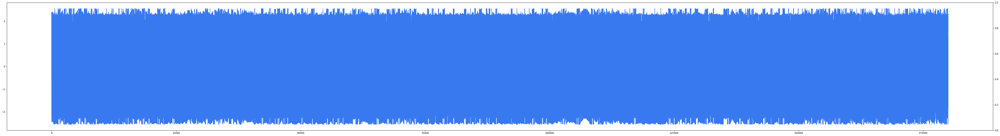

Finishing data 49


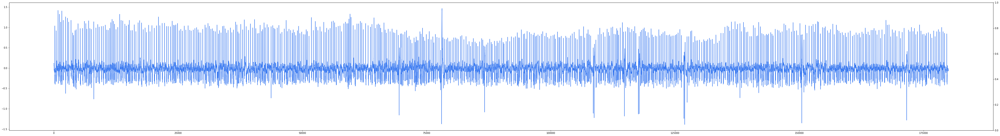

Finishing data 50


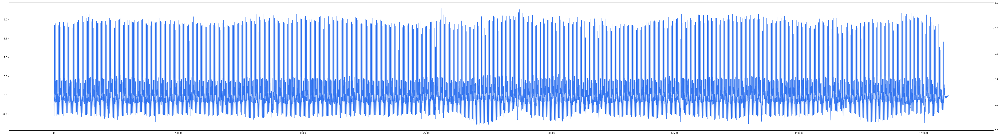

Finishing data 51


In [ ]:
for v in lines:
    dictory = "/content/drive/My Drive/Thesis/Data/sddb/"+v
    
    # Calculate time of start and finish 
    record = wfdb.rdrecord(dictory)
    time = record.sig_len # Get length of time

    # Setup value of time frame
    m = 1000*60*3 # 3 minute

    # setup time start and finish
    start = time-m
    finish = time
    
    # directory for saving file of grayscale
    saveto = "/content/drive/My Drive/Thesis/Picture/SCD/"+v+".png"

    # Load the WFDB record and the physical samples
    record = wfdb.rdrecord(dictory, sampfrom=start, sampto=finish, channels=[0])

    # Use the GQRS algorithm to detect QRS locations in the first channel
    qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

    # Plot results
    conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs, saveto=saveto)

    # open the image and save as grayscale picture
    img = Image.open(saveto).convert('L')
    
    save_img = "/content/drive/My Drive/Thesis/Grayscale/SCD/scd - "+v+".png"
    img.save(save_img)
    
    print('Finishing data '+v)

### Data SCD 49 is not relevant using last 3 minute so try use more small time of the data

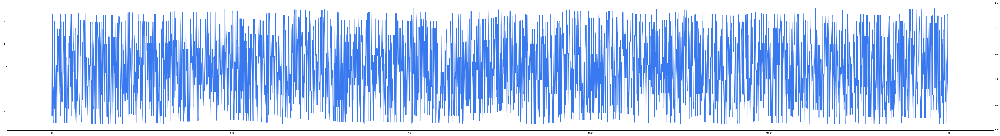

/usr/local/lib/python3.7/dist-packages/PIL/Image.py:2800: DecompressionBombWarning: Image size (120000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  DecompressionBombWarning,


Finishing data 49


In [ ]:
v = '49'
dictory = "/content/drive/My Drive/Thesis/Data/sddb/"+v

# Calculate time of start and finish 
record = wfdb.rdrecord(dictory)
time = record.sig_len # Get length of time

# Setup value of time frame
m = 1000*5 # 5 Second

# setup time start and finish
start = time-m
finish = time

# directory for saving file of grayscale
saveto = "/content/drive/My Drive/Thesis/Picture/SCD/"+v+".png"

# Load the WFDB record and the physical samples
record = wfdb.rdrecord(dictory, sampfrom=start, sampto=finish, channels=[0])

# Use the GQRS algorithm to detect QRS locations in the first channel
qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

# Plot results
conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs, saveto=saveto)

# open the image and save as grayscale picture
img = Image.open(saveto).convert('L')

save_img = "/content/drive/My Drive/Thesis/Grayscale/SCD/scd - "+v+".png"
img.save(save_img)

print('Finishing data '+v)

### Using 5 second last time of data on data SCD 49 is better

### Result of the data is Grayscale picture that save on folder 'Grayscale'